**US Accident**

Predict accident severity using weather, location, time, road features, and traffic-related conditions.

In [ ]:
!nvidia-smi

Mon Aug 10 20:33:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q cudf-cu12 cuml-cu12

In [ ]:
import cudf
import cuml

print(" cuDF version: ", cudf.__version__)
print(" cuML version: ", cuml.__version__)

cuDF version: 26.02.01
cuML version: 26.02.000


In [ ]:
!nvidia-smi

Mon Aug 10 20:33:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.3 MB/s eta 0:00:00


In [ ]:
import openml

dataset = openml.datasets.get_dataset(46650)

print( "Dataset name: ", dataset.name)
print( "Dataset ID: ", dataset.dataset_id)

Dataset name: US_Accidents_March23
Dataset ID: 46650


In [ ]:
print(" Dataset URL:" )
print(dataset.url)

print(" \nDataset format: ")
print(dataset.format)

print(" \nDataset features:" )
print(dataset.features)

Dataset URL:
https://openml.org/data/v1/download/22121343/US_Accidents_March23.arff

Dataset format:
arff

Dataset features:
{0: [0 - ID (string)], 1: [1 - Source (string)], 2: [2 - Severity (numeric)], 3: [3 - Start_Time (string)], 4: [4 - End_Time (string)], 5: [5 - Start_Lat (numeric)], 6: [6 - Start_Lng (numeric)], 7: [7 - End_Lat (numeric)], 8: [8 - End_Lng (numeric)], 9: [9 - Distance(mi) (numeric)], 10: [10 - Description (string)], 11: [11 - Street (string)], 12: [12 - City (string)], 13: [13 - County (string)], 14: [14 - State (string)], 15: [15 - Zipcode (string)], 16: [16 - Country (string)], 17: [17 - Timezone (string)], 18: [18 - Airport_Code (string)], 19: [19 - Weather_Timestamp (string)], 20: [20 - Temperature(F) (numeric)], 21: [21 - Wind_Chill(F) (numeric)], 22: [22 - Humidity(%) (numeric)], 23: [23 - Pressure(in) (numeric)], 24: [24 - Visibility(mi) (numeric)], 25: [25 - Wind_Direction (string)], 26: [26 - Wind_Speed(mph) (numeric)], 27: [27 - Precipitation(in) (numer

In [ ]:
!wget -q "https://openml.org/data/v1/download/22121343/US_Accidents_March23.arff" \
    -O /content/US_Accidents_March23.arff

!ls -lh /content/US_Accidents_March23.arff

-rw-r--r-- 1 root root 3.0G Aug 10 20:41 /content/US_Accidents_March23.arff


In [ ]:
!head -n 20 /content/US_Accidents_March23.arff

%
% This is a countrywide car accident dataset that covers 49 states of the USA. 
% The accident data were collected from February 2016 to March 2023, using multiple 
% APIs that provide streaming traffic incident (or event) data. These APIs broadcast 
% traffic data captured by various entities, including the US and state departments 
% of transportation, law enforcement agencies, traffic cameras, and traffic sensors 
% within the road networks. The dataset currently contains approximately 7.7 million 
% accident records. 
%
% Acknowledgements
% If you use this dataset, please kindly cite the following papers:
%
% Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, and Rajiv Ramnath. "A Countrywide Traffic Accident Dataset.", 2019.
%
% Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, Radu Teodorescu, and Rajiv Ramnath. "Accident Risk Prediction based on Heterogeneous Sparse Data: New Dataset and Insights." In proceedings of the 27th ACM SIGSP

In [ ]:
!grep -n "^@DATA" /content/US_Accidents_March23.arff

86:@DATA


In [ ]:
!sed -n '1,85p' /content/US_Accidents_March23.arff | grep "^@ATTRIBUTE"

@ATTRIBUTE ID STRING
@ATTRIBUTE Source STRING
@ATTRIBUTE Severity INTEGER
@ATTRIBUTE Start_Time STRING
@ATTRIBUTE End_Time STRING
@ATTRIBUTE Start_Lat REAL
@ATTRIBUTE Start_Lng REAL
@ATTRIBUTE End_Lat REAL
@ATTRIBUTE End_Lng REAL
@ATTRIBUTE Distance(mi) REAL
@ATTRIBUTE Description STRING
@ATTRIBUTE Street STRING
@ATTRIBUTE City STRING
@ATTRIBUTE County STRING
@ATTRIBUTE State STRING
@ATTRIBUTE Zipcode STRING
@ATTRIBUTE Country STRING
@ATTRIBUTE Timezone STRING
@ATTRIBUTE Airport_Code STRING
@ATTRIBUTE Weather_Timestamp STRING
@ATTRIBUTE Temperature(F) REAL
@ATTRIBUTE Wind_Chill(F) REAL
@ATTRIBUTE "Humidity(%)" REAL
@ATTRIBUTE Pressure(in) REAL
@ATTRIBUTE Visibility(mi) REAL
@ATTRIBUTE Wind_Direction STRING
@ATTRIBUTE Wind_Speed(mph) REAL
@ATTRIBUTE Precipitation(in) REAL
@ATTRIBUTE Weather_Condition STRING
@ATTRIBUTE Amenity {True, False}
@ATTRIBUTE Bump {True, False}
@ATTRIBUTE Crossing {True, False}
@ATTRIBUTE Give_Way {True, False}
@ATTRIBUTE Junction {True, False}
@ATTRIBUTE No_Exi

In [ ]:
import subprocess

ARFF_FILE = "/content/US_Accidents_March23.arff"
CSV_FILE = "/content/us_accidents_1m.csv"

# Extract first 1,000,000 data rows
cmd = f"""
tail -n +87 "{ARFF_FILE}" | head -n 1000000 > /content/accidents_1m_raw.csv
"""
subprocess.run(cmd, shell=True, check=True)

print(" Done ")

Done!


In [ ]:
columns = [ "ID","Source","Severity","Start_Time","End_Time","Start_Lat","Start_Lng",
    "End_Lat","End_Lng","Distance(mi)","Description", "Street", "City", "County",
    "State","Zipcode", "Country", "Timezone", "Airport_Code", "Weather_Timestamp",
    "Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)","Visibility(mi)",
    "Wind_Direction","Wind_Speed(mph)","Precipitation(in)","Weather_Condition","Amenity",
    "Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout",
    "Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop","Sunrise_Sunset",
    "Civil_Twilight", "Nautical_Twilight","Astronomical_Twilight"
]

print(" Number of columns:", len(columns))

Number of columns: 46


In [ ]:
# Check the extracted file before loading it with cuDF

!wc -l /content/accidents_1m_raw.csv
!head -n 2 /content/accidents_1m_raw.csv

1000000 /content/accidents_1m_raw.csv
A-1,Source2,3,'2016-02-08 05:46:00','2016-02-08 11:00:00',39.865147,-84.058723,?,?,0.01,'Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH-235 State Route 4.','I-70 E',Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,'2016-02-08 05:58:00',36.9,?,91.0,29.68,10.0,Calm,?,0.02,'Light Rain',False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
A-2,Source2,2,'2016-02-08 06:07:59','2016-02-08 06:37:59',39.92805900000001,-82.831184,?,?,0.01,'Accident on Brice Rd at Tussing Rd. Expect delays.','Brice Rd',Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,'2016-02-08 05:51:00',37.9,?,100.0,29.65,10.0,Calm,?,0.0,'Light Rain',False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day


In [ ]:
import cudf

gdf = cudf.read_csv(
    "/content/accidents_1m_raw.csv",
    names=columns,
    na_values=["?"],
    quotechar="'"
)

print("Shape:", gdf.shape)
print("\nData type:")
print(type(gdf))

print("\nFirst 5 rows:")
print(gdf.head())

Shape: (1000000, 46)

Data type:
<class 'cudf.core.dataframe.DataFrame'>

First 5 rows:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng End_Lat End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723    <NA>    <NA>          0.01  ...      False   
1  39.928059 -82.831184    <NA>    <NA>          0.01  ...      False   
2  39.063148 -84.032608    <NA>    <NA>          0.01  ...      False   
3  39.747753 -84.205582    <NA>    <NA>          0.01  ...      False   
4  39.627781 -84.188354    <NA>    <NA>          0.01  ...      False   

   Station   Stop  Traffic_Calming  Traffic_Si

In [ ]:
# ==============================
# Data Quality Check - cuDF
# ==============================

print("Dataset shape:")
print(gdf.shape)

print("\n=== Missing Values ===")
missing = gdf.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\n=== Duplicate Rows ===")
print(gdf.duplicated().sum())

print("\n=== Severity Distribution ===")
print(gdf["Severity"].value_counts().sort_index())

print("\n=== Number of Unique Values ===")
print(gdf.nunique().sort_values(ascending=False))

Dataset shape:
(1000000, 46)

=== Missing Values ===
End_Lat                  1000000
End_Lng                  1000000
Precipitation(in)         477742
Wind_Chill(F)             463236
Wind_Speed(mph)           104991
Visibility(mi)             23899
Weather_Condition          23190
Humidity(%)                21510
Temperature(F)             20462
Wind_Direction             18736
Pressure(in)               17395
Weather_Timestamp          15094
Astronomical_Twilight       8413
Sunrise_Sunset              6825
Civil_Twilight              6825
Nautical_Twilight           6825
Airport_Code                6647
Timezone                    5674
Zipcode                     5359
Turning_Loop                5243
State                       5226
Country                     5226
Amenity                     5226
Bump                        5226
Crossing                    5226
Give_Way                    5226
Junction                    5226
No_Exit                     5226
Railway                

In [ ]:
# Missing percentage using cuDF
missing_report = ( gdf.isnull().sum().to_frame(name="Missing")
)

missing_report["Percent"] = (
    missing_report["Missing"] / len(gdf) * 100
)

missing_report = missing_report[
    missing_report["Missing"] > 0
].sort_values("Percent", ascending=False)

print(missing_report)

                       Missing   Percent
End_Lat                1000000  100.0000
End_Lng                1000000  100.0000
Precipitation(in)       477742   47.7742
Wind_Chill(F)           463236   46.3236
Wind_Speed(mph)         104991   10.4991
Visibility(mi)           23899    2.3899
Weather_Condition        23190    2.3190
Humidity(%)              21510    2.1510
Temperature(F)           20462    2.0462
Wind_Direction           18736    1.8736
Pressure(in)             17395    1.7395
Weather_Timestamp        15094    1.5094
Astronomical_Twilight     8413    0.8413
Sunrise_Sunset            6825    0.6825
Civil_Twilight            6825    0.6825
Nautical_Twilight         6825    0.6825
Airport_Code              6647    0.6647
Timezone                  5674    0.5674
Zipcode                   5359    0.5359
Turning_Loop              5243    0.5243
State                     5226    0.5226
Country                   5226    0.5226
Amenity                   5226    0.5226
Bump            

In [ ]:
# Missing percentage using cuDF
missing_report = (gdf.isnull() .sum().to_frame(name="Missing")
)

missing_report["Percent"] = (missing_report["Missing"] / len(gdf) * 100
)

missing_report = missing_report[missing_report["Missing"] > 0
].sort_values("Percent", ascending=False)

print(missing_report)

                       Missing   Percent
End_Lat                1000000  100.0000
End_Lng                1000000  100.0000
Precipitation(in)       477742   47.7742
Wind_Chill(F)           463236   46.3236
Wind_Speed(mph)         104991   10.4991
Visibility(mi)           23899    2.3899
Weather_Condition        23190    2.3190
Humidity(%)              21510    2.1510
Temperature(F)           20462    2.0462
Wind_Direction           18736    1.8736
Pressure(in)             17395    1.7395
Weather_Timestamp        15094    1.5094
Astronomical_Twilight     8413    0.8413
Sunrise_Sunset            6825    0.6825
Civil_Twilight            6825    0.6825
Nautical_Twilight         6825    0.6825
Airport_Code              6647    0.6647
Timezone                  5674    0.5674
Zipcode                   5359    0.5359
Turning_Loop              5243    0.5243
State                     5226    0.5226
Country                   5226    0.5226
Amenity                   5226    0.5226
Bump            

In [ ]:
gdf = gdf.drop(columns=["End_Lat", "End_Lng"])

print(gdf.shape)

(1000000, 44)


In [ ]:
print(gdf.dtypes)

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)            object
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)         object
Weather_Condition         object
Amenity                     bool
Bump                        bool
Crossing                    bool
Give_Way  

In [ ]:
print("\nNumeric columns:")
print(gdf.select_dtypes(include=["number"]).columns)

print("\nBoolean columns:")
print(gdf.select_dtypes(include=["bool"]).columns)


Numeric columns:
Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Wind_Speed(mph)'],
      dtype='object')

Boolean columns:
Index(['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
       'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
       'Traffic_Signal'],
      dtype='object')


In [ ]:
# Handle missing numerical values using median


numeric_impute_cols = [ "Temperature(F)", "Wind_Chill(F)","Humidity(%)","Pressure(in)",
    "Wind_Speed(mph)"
]

for col in numeric_impute_cols:
    median_value = gdf[col].median()
    gdf[col] = gdf[col].fillna(median_value)

print("Remaining missing values:")
print(gdf[numeric_impute_cols].isnull().sum())

Remaining missing values:
Temperature(F)     0
Wind_Chill(F)      0
Humidity(%)        0
Pressure(in)       0
Wind_Speed(mph)    0
dtype: int64


In [ ]:
!ls -lh /content/accidents_1m_raw.csv

-rw-r--r-- 1 root root 371M Aug 10 20:41 /content/accidents_1m_raw.csv


In [ ]:
import cudf

gdf = cudf.read_csv(
    "/content/accidents_1m_raw.csv",
    names=columns,
    na_values=["?"],
    quotechar="'"
)

print("Shape:", gdf.shape)
print(type(gdf))

Shape: (1000000, 46)
<class 'cudf.core.dataframe.DataFrame'>


In [ ]:
# Remove columns that are missing
gdf = gdf.drop(columns=["End_Lat", "End_Lng"])

print("Shape:", gdf.shape)

Shape: (1000000, 44)


In [ ]:
print("Precipitation dtype:")
print(gdf["Precipitation(in)"].dtype)

print("\nNon-numeric values:")
print(gdf["Precipitation(in)"].value_counts().head(20)
)

Precipitation dtype:
object

Non-numeric values:
Precipitation(in)
0.0     460321
0.01     16302
0.02      8430
0.03      5454
0.04      4153
0.05      3267
0.06      2702
0.07      2144
0.08      1819
0.09      1580
0.1       1384
0.11      1120
0.12      1061
0.13       870
0.14       841
0.15       700
0.16       673
Fair       621
0.18       504
0.17       494
Name: count, dtype: int64


In [ ]:
# Convert Precipitation to numeric safely
gdf["Precipitation(in)"] = cudf.to_numeric( gdf["Precipitation(in)"],errors="coerce"
)

print("Dtype:")
print(gdf["Precipitation(in)"].dtype)

print("\nMissing after conversion:")
print(gdf["Precipitation(in)"].isnull().sum())

Dtype:
float64

Missing after conversion:
479333


In [ ]:

# Fill missing Precipitation values using the median

precip_median = gdf["Precipitation(in)"].median()

gdf["Precipitation(in)"] = (
    gdf["Precipitation(in)"].fillna(precip_median)
)

print("Precipitation median:", precip_median)
print("Remaining missing:", gdf["Precipitation(in)"].isnull().sum())

Precipitation median: 0.0
Remaining missing: 0


In [ ]:
# Check numerical columns after imputation

numeric_cols = [ "Severity", "Start_Lat", "Start_Lng","Distance(mi)","Temperature(F)",
    "Wind_Chill(F)","Humidity(%)","Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Precipitation(in)"
]

print(gdf[numeric_cols].isnull().sum())

Severity                  0
Start_Lat                 0
Start_Lng                 0
Distance(mi)              0
Temperature(F)        20462
Wind_Chill(F)        463236
Humidity(%)           21510
Pressure(in)          17395
Visibility(mi)        23899
Wind_Speed(mph)      104991
Precipitation(in)         0
dtype: int64


In [ ]:
for col in numeric_impute_cols:
    print(col, "->", gdf[col].dtype)

Temperature(F) -> float64
Wind_Chill(F) -> float64
Humidity(%) -> float64
Pressure(in) -> float64
Wind_Speed(mph) -> float64


In [ ]:
# Convert Visibility safely to numeric
gdf["Visibility(mi)"] = cudf.to_numeric(gdf["Visibility(mi)"],errors="coerce"
)

print("Dtype:", gdf["Visibility(mi)"].dtype)
print("Missing:", gdf["Visibility(mi)"].isnull().sum())

Dtype: float64
Missing: 25312


In [ ]:
# Median imputation for numerical columns
numeric_impute_cols = [ "Temperature(F)", "Wind_Chill(F)","Humidity(%)","Pressure(in)",
    "Visibility(mi)","Wind_Speed(mph)","Precipitation(in)"
]

for col in numeric_impute_cols:
    median_value = gdf[col].median()
    gdf[col] = gdf[col].fillna(median_value)

print("Remaining missing values:")
print(gdf[numeric_impute_cols].isnull().sum())

Remaining missing values:
Temperature(F)       0
Wind_Chill(F)        0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
dtype: int64


In [ ]:
categorical_cols = ["Source","City","County","State","Country","Timezone",
    "Wind_Direction","Weather_Condition","Sunrise_Sunset","Civil_Twilight",
    "Nautical_Twilight","Astronomical_Twilight"
]

for col in categorical_cols:
    gdf[col] = gdf[col].fillna("Unknown")

print("Remaining categorical missing:")
print(gdf[categorical_cols].isnull().sum())

Remaining categorical missing:
Source                   0
City                     0
County                   0
State                    0
Country                  0
Timezone                 0
Wind_Direction           0
Weather_Condition        0
Sunrise_Sunset           0
Civil_Twilight           0
Nautical_Twilight        0
Astronomical_Twilight    0
dtype: int64


In [ ]:
boolean_cols = [ "Amenity","Bump","Crossing","Give_Way",
    "Junction","No_Exit","Railway","Roundabout","Station",
    "Stop","Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

for col in boolean_cols:
    gdf[col] = gdf[col].fillna(False)

print("Remaining Boolean missing:")
print(gdf[boolean_cols].isnull().sum())

Remaining Boolean missing:
Amenity            0
Bump               0
Crossing           0
Give_Way           0
Junction           0
No_Exit            0
Railway            0
Roundabout         0
Station            0
Stop               0
Traffic_Calming    0
Traffic_Signal     0
Turning_Loop       0
dtype: int64


In [ ]:
print("=== Remaining Missing Values ===")

missing = gdf.isnull().sum()
print(missing[missing > 0])

print("\n=== Shape ===")
print(gdf.shape)

print("\n=== Duplicate Rows ===")
print(gdf.duplicated().sum())

print("\n=== Severity ===")
print(gdf["Severity"].value_counts().sort_index())

=== Remaining Missing Values ===
Description              1
Street                3139
Zipcode               5359
Airport_Code          6647
Weather_Timestamp    15094
dtype: int64

=== Shape ===
(1000000, 44)

=== Duplicate Rows ===
0

=== Severity ===
Severity
1     38381
2    606235
3    352187
4      3197
Name: count, dtype: int64


In [ ]:
# Remove high-cardinality / unnecessary columns

columns_to_drop = ["Description","Street","Zipcode","Airport_Code","Weather_Timestamp"
]

gdf = gdf.drop(columns=columns_to_drop)

print("Shape after dropping unnecessary columns:")
print(gdf.shape)

print("\nRemaining missing values:")
missing = gdf.isnull().sum()
print(missing[missing > 0])

Shape after dropping unnecessary columns:
(1000000, 39)

Remaining missing values:
Series([], dtype: int64)


Featuer Engineering

In [ ]:
print("Start_Time:", gdf["Start_Time"].dtype)
print("End_Time:", gdf["End_Time"].dtype)

Start_Time: object
End_Time: object


In [ ]:
# Convert datetime columns using fixed format

gdf["Start_Time"] = cudf.to_datetime(
    gdf["Start_Time"],
    format="%Y-%m-%d %H:%M:%S"
)

gdf["End_Time"] = cudf.to_datetime(
    gdf["End_Time"],
    format="%Y-%m-%d %H:%M:%S"
)

print("Start_Time:", gdf["Start_Time"].dtype)
print("End_Time:", gdf["End_Time"].dtype)

Start_Time: datetime64[ns]
End_Time: datetime64[ns]


In [ ]:
# Feature Engineering from time columns

# Accident duration in minutes
gdf["Duration_Minutes"] = (
    (gdf["End_Time"] - gdf["Start_Time"])
    .dt.total_seconds() / 60
)

# Time-based features from Start_Time
gdf["Hour"] = gdf["Start_Time"].dt.hour
gdf["Day"] = gdf["Start_Time"].dt.day
gdf["Month"] = gdf["Start_Time"].dt.month
gdf["Weekday"] = gdf["Start_Time"].dt.weekday

# Weekend: Saturday/Sunday
gdf["Weekend"] = gdf["Weekday"] >= 5

print(
    gdf[
        ["Duration_Minutes","Hour","Day","Month","Weekday", "Weekend"
        ]
    ].head()
)

   Duration_Minutes  Hour  Day  Month  Weekday  Weekend
0             314.0     5    8      2        0    False
1              30.0     6    8      2        0    False
2              30.0     6    8      2        0    False
3              30.0     7    8      2        0    False
4              30.0     7    8      2        0    False


In [ ]:
new_time_features = ["Duration_Minutes","Hour","Day","Month","Weekday", "Weekend"
]

print(gdf[new_time_features].isnull().sum())

Duration_Minutes    0
Hour                0
Day                 0
Month               0
Weekday             0
Weekend             0
dtype: int64


In [ ]:
# Check accident duration

print("Duration statistics:")
print(gdf["Duration_Minutes"].describe())

print("\nNegative durations:")
print((gdf["Duration_Minutes"] < 0).sum())

print("\nZero durations:")
print((gdf["Duration_Minutes"] == 0).sum())

Duration statistics:
count    1000000.000000
mean          46.430222
std          352.400413
min            3.683333
25%           29.683333
50%           44.166667
75%           47.916667
max       336960.000000
Name: Duration_Minutes, dtype: float64

Negative durations:
0

Zero durations:
0


In [ ]:
# Check extreme accident durations


print("Duration > 24 hours:",
      (gdf["Duration_Minutes"] > 1440).sum())

print("Duration > 7 days:",
      (gdf["Duration_Minutes"] > 10080).sum())

print("Duration > 30 days:",
      (gdf["Duration_Minutes"] > 43200).sum())

print("Duration > 1 year:",
      (gdf["Duration_Minutes"] > 525600).sum())

Duration > 24 hours: 106
Duration > 7 days: 9
Duration > 30 days: 2
Duration > 1 year: 0


In [ ]:
# Inspect extreme duration values


print(
    gdf[
        ["Start_Time", "End_Time", "Duration_Minutes", "Severity"]
    ]
    .sort_values("Duration_Minutes", ascending=False)
    .head(10)
)

                Start_Time            End_Time  Duration_Minutes  Severity
391245 2016-11-08 01:00:00 2017-06-30 01:00:00     336960.000000         2
436505 2017-05-03 11:17:26 2017-06-30 03:00:00      83022.566667         3
589913 2022-05-26 17:09:35 2022-06-11 15:09:00      22919.416667         2
636910 2022-04-05 04:39:20 2022-04-18 07:27:24      18888.066667         3
734391 2022-01-10 04:04:27 2022-01-18 09:26:00      11841.550000         3
700696 2022-02-06 18:11:00 2022-02-14 08:08:00      10917.000000         3
874292 2021-09-17 05:06:58 2021-09-24 10:37:00      10410.033333         2
801112 2021-11-15 01:50:36 2021-11-22 02:49:00      10138.400000         3
699406 2022-02-08 06:55:06 2022-02-15 07:24:00      10108.900000         3
900419 2021-08-31 15:09:35 2021-09-07 05:22:00       9492.416667         3


In [ ]:
# Cap extreme duration values
# Keep all 1,000,000 records

duration_cap = gdf["Duration_Minutes"].quantile(0.99)

print("99th percentile:", duration_cap)

gdf["Duration_Minutes"] = gdf["Duration_Minutes"].clip(
    upper=duration_cap
)

print("\nNew Duration statistics:")
print(gdf["Duration_Minutes"].describe())

99th percentile: 150.01666666666668

New Duration statistics:
count    1000000.000000
mean          44.805597
std           21.236449
min            3.683333
25%           29.683333
50%           44.166667
75%           47.916667
max          150.016667
Name: Duration_Minutes, dtype: float64


In [ ]:
# Remove original datetime columns


gdf = gdf.drop(
    columns=["Start_Time", "End_Time"]
)

print("Shape:", gdf.shape)
print("Columns:")
print(gdf.columns)

Shape: (1000000, 43)
Columns:
Index(['ID', 'Source', 'Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)',
       'City', 'County', 'State', 'Country', 'Timezone', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
       'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
       'Duration_Minutes', 'Hour', 'Day', 'Month', 'Weekday', 'Weekend'],
      dtype='object')


In [ ]:
# Remove ID because it is only an identifier
gdf = gdf.drop(columns=["ID"])

print("Shape:", gdf.shape)

Shape: (1000000, 42)


In [ ]:
numeric_cols = gdf.select_dtypes(
    include=["float32", "float64", "int8", "int16", "int32", "int64"]
).columns

boolean_cols = gdf.select_dtypes(
    include=["bool"]
).columns

print("Numeric columns:")
print(numeric_cols)

print("\nBoolean columns:")
print(boolean_cols)

Numeric columns:
Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Duration_Minutes', 'Hour',
       'Day', 'Month', 'Weekday'],
      dtype='object')

Boolean columns:
Index(['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
       'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
       'Traffic_Signal', 'Weekend'],
      dtype='object')


In [ ]:
feature_cols = ["Start_Lat","Start_Lng", "Distance(mi)", "Temperature(F)", "Wind_Chill(F)",
    "Humidity(%)", "Pressure(in)","Visibility(mi)","Wind_Speed(mph)","Precipitation(in)",
    "Duration_Minutes","Hour","Day", "Month","Weekday","Amenity","Bump","Crossing",
    "Give_Way","Junction","No_Exit","Railway","Roundabout","Station","Stop",
    "Traffic_Calming","Traffic_Signal","Weekend"
]

In [ ]:
# Final check before ML


print("Feature matrix shape:")
print(gdf[feature_cols].shape)

print("\nMissing values:")
print(gdf[feature_cols].isnull().sum().sum())

print("\nTarget distribution:")
print(gdf["Severity"].value_counts().sort_index())

Feature matrix shape:
(1000000, 28)

Missing values:
0

Target distribution:
Severity
1     38381
2    606235
3    352187
4      3197
Name: count, dtype: int64


split

In [ ]:
# Prepare X and y


X = gdf[feature_cols]
y = gdf["Severity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000000, 28)
y shape: (1000000,)


In [ ]:
# Train / Test Split

from cuml.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800000, 28)
X_test: (200000, 28)
y_train: (800000,)
y_test: (200000,)


In [ ]:
# Feature Scaling using cuML


from cuml.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Data type:", type(X_train_scaled))

X_train_scaled shape: (800000, 28)
X_test_scaled shape: (200000, 28)
Data type: <class 'cudf.core.dataframe.DataFrame'>


Modeling

In [ ]:
# Model 1: Logistic Regression using cuML


import time
from cuml.linear_model import LogisticRegression

# Start timer
start_time = time.perf_counter()

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# End timer
logistic_train_time = time.perf_counter() - start_time

print("Logistic Regression training completed!")
print("Training time:", round(logistic_train_time, 3), "seconds")

Logistic Regression training completed!
Training time: 3.766 seconds


In [ ]:
# Logistic Regression - Inference


start_time = time.perf_counter()

y_pred_logistic = logistic_model.predict(X_test_scaled)

logistic_inference_time = time.perf_counter() - start_time

print("Inference time:", round(logistic_inference_time, 3), "seconds")
print("Predictions shape:", y_pred_logistic.shape)

Inference time: 0.481 seconds
Predictions shape: (200000,)


In [ ]:
# Evaluate Logistic Regression
from sklearn.metrics import accuracy_score, f1_score

# Convert only predictions and target for evaluation
y_test_cpu = y_test.to_numpy()
y_pred_logistic_cpu = y_pred_logistic.to_numpy()

logistic_accuracy = accuracy_score(
    y_test_cpu,
    y_pred_logistic_cpu
)

logistic_f1_macro = f1_score(
    y_test_cpu,
    y_pred_logistic_cpu,
    average="macro"
)

logistic_f1_weighted = f1_score(
    y_test_cpu,
    y_pred_logistic_cpu,
    average="weighted"
)

print("=== Logistic Regression Results ===")
print("Accuracy:", round(logistic_accuracy, 4))
print("Macro F1:", round(logistic_f1_macro, 4))
print("Weighted F1:", round(logistic_f1_weighted, 4))

=== Logistic Regression Results ===
Accuracy: 0.6387
Macro F1: 0.2974
Weighted F1: 0.5938


In [ ]:
# Model 2: Random Forest using cuML

import time
from cuml.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    random_state=42
)

# Training time
start_time = time.perf_counter()

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_train_time = time.perf_counter() - start_time

print("Random Forest training completed!")
print("Training time:", round(rf_train_time, 3), "seconds")

Random Forest training completed!
Training time: 7.699 seconds


In [ ]:
# Random Forest - Inference

start_time = time.perf_counter()

y_pred_rf = rf_model.predict(X_test_scaled)

rf_inference_time = time.perf_counter() - start_time

print("Inference time:", round(rf_inference_time, 3), "seconds")
print("Predictions shape:", y_pred_rf.shape)

Inference time: 2.507 seconds
Predictions shape: (200000,)


In [ ]:
# Evaluate Random Forest


from sklearn.metrics import accuracy_score, f1_score

y_pred_rf_cpu = y_pred_rf.to_numpy()

rf_accuracy = accuracy_score(
    y_test_cpu,
    y_pred_rf_cpu
)

rf_f1_macro = f1_score(
    y_test_cpu,
    y_pred_rf_cpu,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test_cpu,
    y_pred_rf_cpu,
    average="weighted"
)

print("=== Random Forest Results ===")
print("Accuracy:", round(rf_accuracy, 4))
print("Macro F1:", round(rf_f1_macro, 4))
print("Weighted F1:", round(rf_f1_weighted, 4))

=== Random Forest Results ===
Accuracy: 0.7284
Macro F1: 0.4111
Weighted F1: 0.7145


In [ ]:
# Random Forest Feature Importance

import pandas as pd

feature_importance = rf_model.feature_importances_

print("Feature importance shape:", feature_importance.shape)

Feature importance shape: (28,)


In [ ]:
# Feature Importance Table

feature_names = X_train_scaled.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=== Random Forest Feature Importance ===")
print(importance_df)

=== Random Forest Feature Importance ===
    Feature  Importance
0        26    0.151265
1         1    0.128054
2         0    0.121223
3        17    0.080365
4        11    0.061657
5        10    0.054499
6         4    0.052410
7         2    0.049468
8        13    0.041105
9         6    0.040677
10        3    0.032829
11       24    0.028591
12       14    0.028511
13       27    0.024693
14        5    0.022647
15        8    0.020385
16       12    0.019929
17       19    0.015667
18        7    0.007377
19       23    0.005789
20        9    0.004362
21       15    0.003756
22       21    0.002550
23       18    0.001629
24       20    0.000295
25       25    0.000233
26       16    0.000030
27       22    0.000004


In [ ]:
# Top 10 Features


top_10_features = importance_df.head(10)

print("=== Top 10 Important Features ===")
print(top_10_features)

=== Top 10 Important Features ===
   Feature  Importance
0       26    0.151265
1        1    0.128054
2        0    0.121223
3       17    0.080365
4       11    0.061657
5       10    0.054499
6        4    0.052410
7        2    0.049468
8       13    0.041105
9        6    0.040677


In [ ]:
# Restore Original Feature Names

feature_names = ['Start_Lat','Start_Lng','Distance(mi)','Temperature(F)','Wind_Chill(F)',
    'Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)','Amenity','Bump',
    'Crossing','Give_Way','Junction','No_Exit','Railway','Roundabout','Station',
    'Stop','Traffic_Calming','Traffic_Signal','Duration_Minutes','Hour','Day',
    'Month','Weekday','Weekend'
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=== Top 10 Important Features ===")
print(importance_df.head(10))

=== Top 10 Important Features ===
         Feature  Importance
0        Weekday    0.151265
1      Start_Lng    0.128054
2      Start_Lat    0.121223
3     Roundabout    0.080365
4           Bump    0.061657
5        Amenity    0.054499
6  Wind_Chill(F)    0.052410
7   Distance(mi)    0.049468
8       Give_Way    0.041105
9   Pressure(in)    0.040677


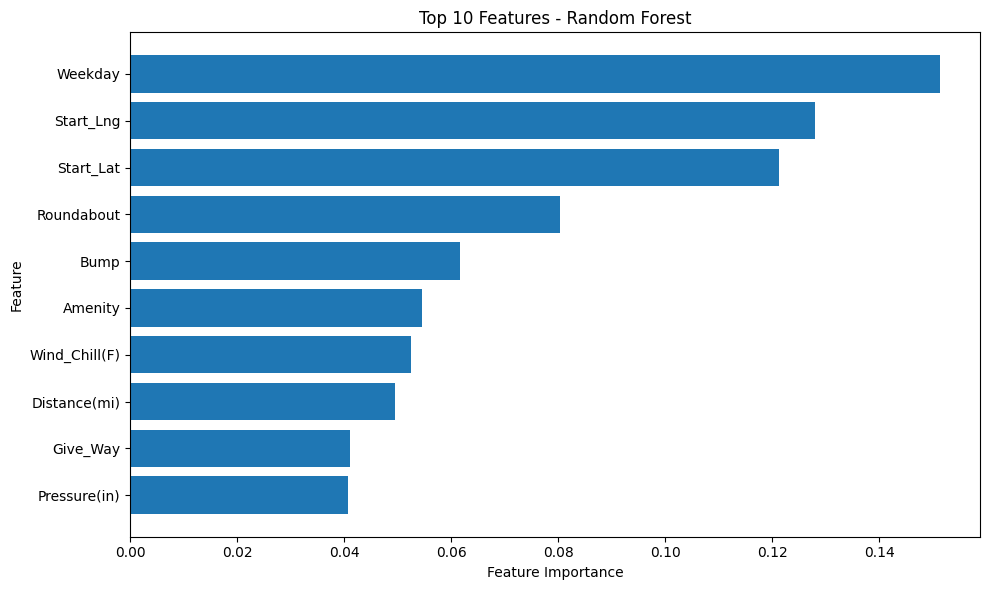

In [ ]:
# Random Forest - Top 10 Feature Importance


import matplotlib.pyplot as plt

top_10 = importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Random Forest")

plt.tight_layout()
plt.show()

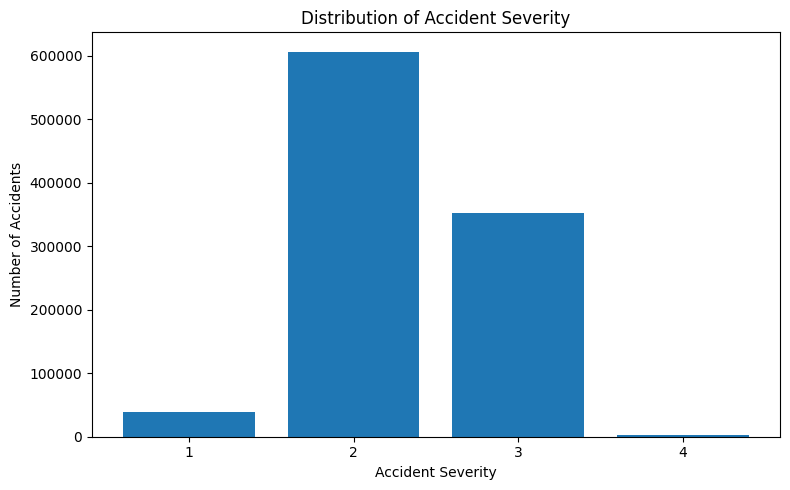

In [ ]:
# EDA Figure 1 - Severity Distribution

import matplotlib.pyplot as plt

# Count severity values on GPU
severity_counts = gdf["Severity"].value_counts().sort_index()

# Move only the small result to CPU
severity_counts = severity_counts.to_pandas()

plt.figure(figsize=(8, 5))

plt.bar(
    severity_counts.index.astype(str),
    severity_counts.values
)

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Distribution of Accident Severity")

plt.tight_layout()
plt.show()

/tmp/ipykernel_878/3175795579.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


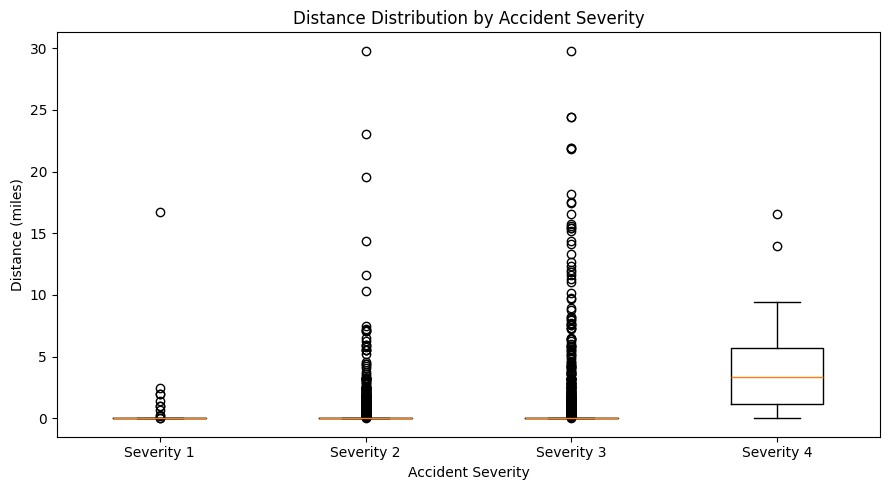

In [ ]:
# EDA Figure 2 - Distance by Severity
import matplotlib.pyplot as plt

# Take a small sample only for visualization
sample_df = gdf[["Distance(mi)", "Severity"]].sample(
    n=10000,
    random_state=42
)

# Convert only the small sample to pandas
sample_df = sample_df.to_pandas()

plt.figure(figsize=(9, 5))

data = [
    sample_df[sample_df["Severity"] == severity]["Distance(mi)"]
    for severity in [1, 2, 3, 4]
]

plt.boxplot(
    data,
    labels=["Severity 1", "Severity 2", "Severity 3", "Severity 4"]
)

plt.xlabel("Accident Severity")
plt.ylabel("Distance (miles)")
plt.title("Distance Distribution by Accident Severity")

plt.tight_layout()
plt.show()

In [ ]:
# Model 3: K-Nearest Neighbors using cuML
import time
from cuml.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Training time
start_time = time.perf_counter()

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_train_time = time.perf_counter() - start_time

print("KNN training completed!")
print("Training time:", round(knn_train_time, 3), "seconds")

KNN training completed!
Training time: 0.067 seconds


In [ ]:
# KNN - Inference

start_time = time.perf_counter()

y_pred_knn = knn_model.predict(X_test_scaled)

knn_inference_time = time.perf_counter() - start_time

print("Inference time:", round(knn_inference_time, 3), "seconds")
print("Predictions shape:", y_pred_knn.shape)

Inference time: 8.545 seconds
Predictions shape: (200000,)


In [ ]:
# Evaluate KNN

from sklearn.metrics import accuracy_score, f1_score

y_pred_knn_cpu = y_pred_knn.to_numpy()

knn_accuracy = accuracy_score(
    y_test_cpu,
    y_pred_knn_cpu
)

knn_f1_macro = f1_score(
    y_test_cpu,
    y_pred_knn_cpu,
    average="macro"
)

knn_f1_weighted = f1_score(
    y_test_cpu,
    y_pred_knn_cpu,
    average="weighted"
)

print("=== KNN Results ===")
print("Accuracy:", round(knn_accuracy, 4))
print("Macro F1:", round(knn_f1_macro, 4))
print("Weighted F1:", round(knn_f1_weighted, 4))

=== KNN Results ===
Accuracy: 0.6711
Macro F1: 0.4637
Weighted F1: 0.6658


GPU Preformance

In [ ]:
!nvidia-smi

Mon Aug 10 20:42:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             36W /   70W |     923MiB /  15360MiB |     55%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ==========================================
# GPU Utilization Monitoring
# Logistic Regression
# ==========================================

import subprocess
import threading
import time

gpu_samples = []
monitoring = True

def monitor_gpu():
    while monitoring:
        result = subprocess.check_output([
            "nvidia-smi",
            "--query-gpu=utilization.gpu,memory.used",
            "--format=csv,noheader,nounits"
        ]).decode().strip()

        util, memory = result.split(",")
        gpu_samples.append({
            "utilization": float(util.strip()),
            "memory": float(memory.strip())
        })

        time.sleep(0.1)

# Start GPU monitoring
monitor_thread = threading.Thread(target=monitor_gpu)
monitor_thread.start()

# Run inference
start_time = time.perf_counter()

y_pred_logistic_monitor = logistic_model.predict(X_test_scaled)

# Synchronize GPU
import cupy as cp
cp.cuda.Stream.null.synchronize()

logistic_monitor_time = time.perf_counter() - start_time

# Stop monitoring
monitoring = False
monitor_thread.join()

# Results
avg_gpu_util = sum(x["utilization"] for x in gpu_samples) / len(gpu_samples)
max_gpu_util = max(x["utilization"] for x in gpu_samples)
max_gpu_memory = max(x["memory"] for x in gpu_samples)

print("=== Logistic Regression GPU Performance ===")
print("Inference time:", round(logistic_monitor_time, 4), "seconds")
print("Average GPU Utilization:", round(avg_gpu_util, 2), "%")
print("Maximum GPU Utilization:", round(max_gpu_util, 2), "%")
print("Maximum GPU Memory:", round(max_gpu_memory, 2), "MiB")
print("GPU Samples:", len(gpu_samples))

=== Logistic Regression GPU Performance ===
Inference time: 0.0142 seconds
Average GPU Utilization: 0.0 %
Maximum GPU Utilization: 0.0 %
Maximum GPU Memory: 925.0 MiB
GPU Samples: 1


In [ ]:
# GPU Performance Monitoring
# Logistic Regression
# Repeated Inference for GPU Measurement

import subprocess
import threading
import time
import cupy as cp

gpu_samples = []
monitoring = True


def monitor_gpu():
    while monitoring:
        try:
            result = subprocess.check_output([
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used",
                "--format=csv,noheader,nounits"
            ]).decode().strip()

            util, memory = result.split(",")

            gpu_samples.append({
                "utilization": float(util.strip()),
                "memory": float(memory.strip())
            })

        except Exception:
            pass

        time.sleep(0.05)


# Start GPU monitoring

monitor_thread = threading.Thread(target=monitor_gpu)
monitor_thread.start()


# Repeated inference

start_time = time.perf_counter()

for i in range(50):
    y_temp = logistic_model.predict(X_test_scaled)

    # Synchronize GPU
    cp.cuda.Stream.null.synchronize()


logistic_monitor_time = time.perf_counter() - start_time


# Stop monitoring

monitoring = False
monitor_thread.join()


# Calculate GPU metrics

avg_gpu_util = (
    sum(x["utilization"] for x in gpu_samples)
    / len(gpu_samples)
)

max_gpu_util = max(
    x["utilization"] for x in gpu_samples
)

max_gpu_memory = max(
    x["memory"] for x in gpu_samples
)


# Results

print("=== Logistic Regression GPU Performance ===")
print("Repeated Inference Runs: 50")
print(
    "Total Inference Time:",
    round(logistic_monitor_time, 4),
    "seconds"
)
print(
    "Average GPU Utilization:",
    round(avg_gpu_util, 2),
    "%"
)
print(
    "Maximum GPU Utilization:",
    round(max_gpu_util, 2),
    "%"
)
print(
    "Maximum GPU Memory:",
    round(max_gpu_memory, 2),
    "MiB"
)
print(
    "GPU Samples:",
    len(gpu_samples)
)

=== Logistic Regression GPU Performance ===
Repeated Inference Runs: 50
Total Inference Time: 0.4582 seconds
Average GPU Utilization: 51.14 %
Maximum GPU Utilization: 89.0 %
Maximum GPU Memory: 979.0 MiB
GPU Samples: 7


In [ ]:
# GPU Performance Monitoring
# KNN Inference

import subprocess
import threading
import time
import cupy as cp

gpu_samples = []
monitoring = True


def monitor_gpu():
    while monitoring:
        try:
            result = subprocess.check_output([
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used",
                "--format=csv,noheader,nounits"
            ]).decode().strip()

            util, memory = result.split(",")

            gpu_samples.append({
                "utilization": float(util.strip()),
                "memory": float(memory.strip())
            })

        except Exception:
            pass

        time.sleep(0.05)


# Start monitoring
monitor_thread = threading.Thread(target=monitor_gpu)
monitor_thread.start()


# KNN Inference

start_time = time.perf_counter()

y_pred_knn_monitor = knn_model.predict(X_test_scaled)

# Wait for GPU operations to finish
cp.cuda.Stream.null.synchronize()

knn_monitor_time = time.perf_counter() - start_time


# Stop monitoring
monitoring = False
monitor_thread.join()


# Calculate GPU metrics


if len(gpu_samples) > 0:

    avg_gpu_util = (
        sum(x["utilization"] for x in gpu_samples)
        / len(gpu_samples)
    )

    max_gpu_util = max(
        x["utilization"] for x in gpu_samples
    )

    max_gpu_memory = max(
        x["memory"] for x in gpu_samples
    )

else:
    avg_gpu_util = 0
    max_gpu_util = 0
    max_gpu_memory = 0


# Results

print("=== KNN GPU Performance ===")
print("Inference time:", round(knn_monitor_time, 4), "seconds")
print("Average GPU Utilization:", round(avg_gpu_util, 2), "%")
print("Maximum GPU Utilization:", round(max_gpu_util, 2), "%")
print("Maximum GPU Memory:", round(max_gpu_memory, 2), "MiB")
print("GPU Samples:", len(gpu_samples))

=== KNN GPU Performance ===
Inference time: 8.1221 seconds
Average GPU Utilization: 97.64 %
Maximum GPU Utilization: 100.0 %
Maximum GPU Memory: 969.0 MiB
GPU Samples: 110


Model Comperison

In [ ]:
# Model Comparison


import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],

    "Accuracy": [
        0.6387,
        0.7284,
        0.6711
    ],

    "Macro F1": [
        0.2974,
        0.4111,
        0.4637
    ],

    "Weighted F1": [
        0.5938,
        0.7145,
        0.6658
    ],

    "Training Time (s)": [
        5.711,
        8.567,
        0.067
    ],

    "Inference Time (s)": [
        0.774,
        2.566,
        9.675
    ]
})

print(results)

                 Model  Accuracy  Macro F1  Weighted F1  Training Time (s)  \
0  Logistic Regression    0.6387    0.2974       0.5938              5.711   
1        Random Forest    0.7284    0.4111       0.7145              8.567   
2                  KNN    0.6711    0.4637       0.6658              0.067   

   Inference Time (s)  
0               0.774  
1               2.566  
2               9.675  


In [ ]:
# Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test.to_numpy(),
    y_pred_rf.to_numpy()
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[   707   6663    397      0]
 [   147 100770  20125      0]
 [    30  26329  44184      1]
 [     0    165    469     13]]


In [ ]:
# Random Forest Classification Report

from sklearn.metrics import classification_report

# Convert cuDF to NumPy
y_true_rf = y_test.to_numpy()
y_pred_rf_np = y_pred_rf.to_numpy()

print("=== Random Forest Classification Report ===")

print(
    classification_report(
        y_true_rf,
        y_pred_rf_np,
        labels=[1, 2, 3, 4],
        digits=4
    )
)

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           1     0.7998    0.0910    0.1634      7767
           2     0.7524    0.8325    0.7904    121042
           3     0.6779    0.6263    0.6511     70544
           4     0.9286    0.0201    0.0393       647

    accuracy                         0.7284    200000
   macro avg     0.7897    0.3925    0.4111    200000
weighted avg     0.7286    0.7284    0.7145    200000



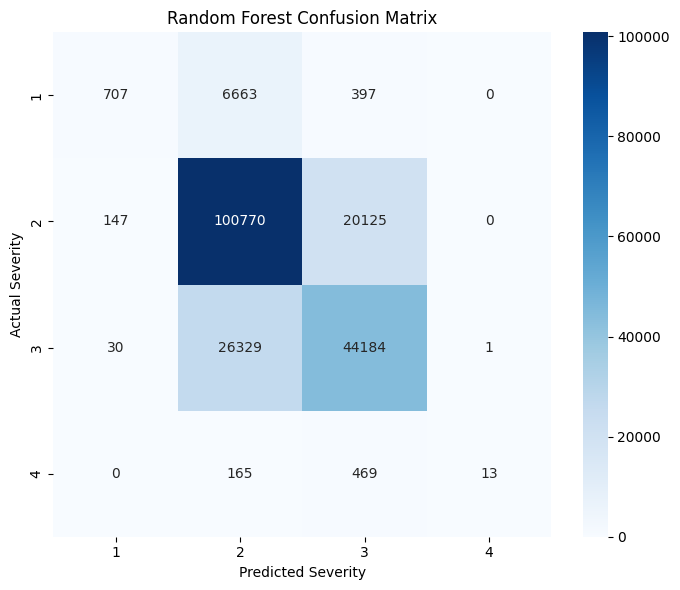

In [ ]:
# Random Forest Confusion Matrix Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4]
)

plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

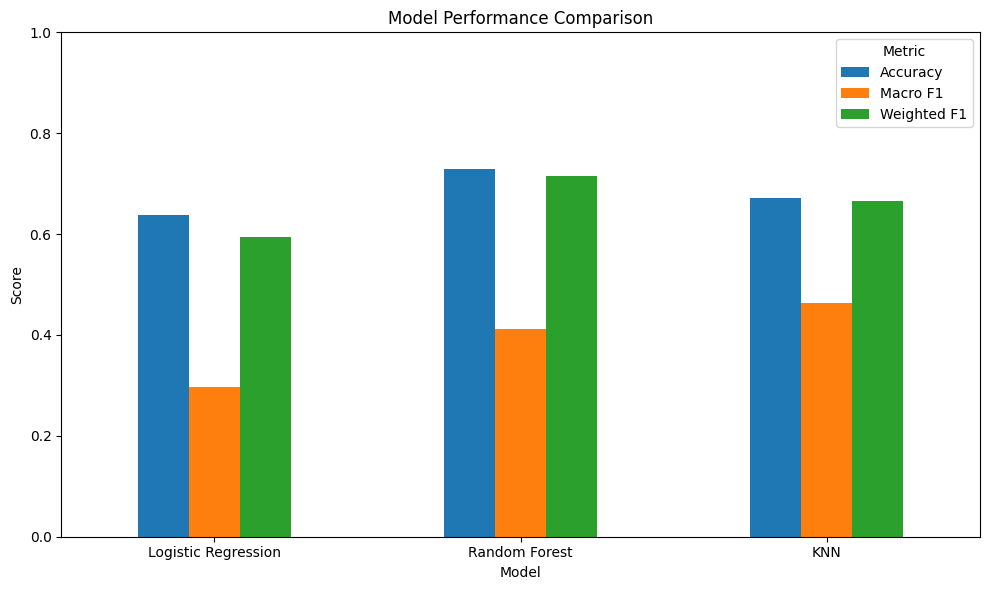

In [ ]:
# Model Performance Comparison

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1", "Weighted F1"]

results_plot = results.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

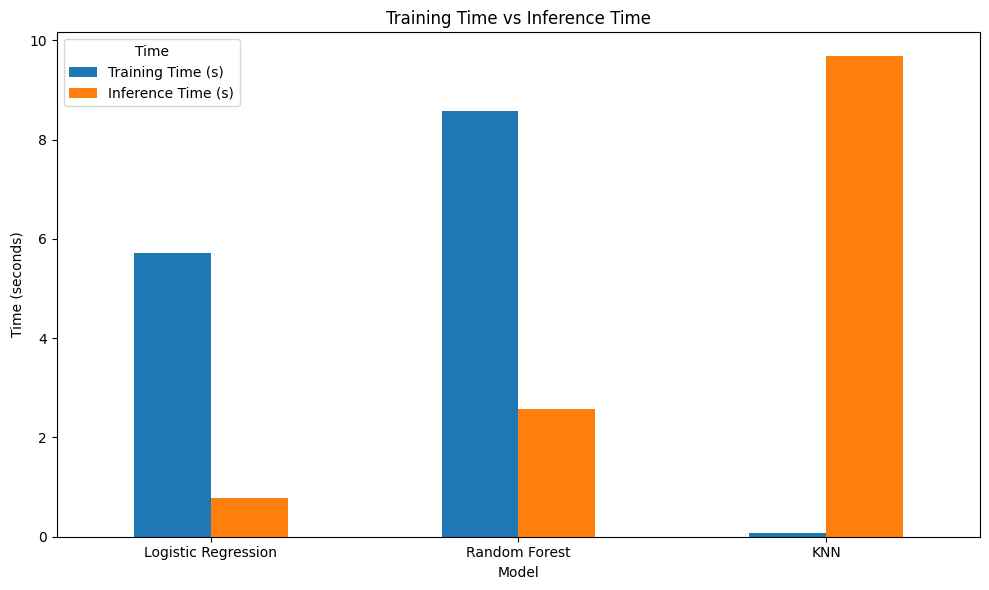

In [ ]:
# Training vs Inference Time

import matplotlib.pyplot as plt

time_results = results.set_index("Model")[
    ["Training Time (s)", "Inference Time (s)"]
]

time_results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training Time vs Inference Time")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)
plt.legend(title="Time")
plt.tight_layout()
plt.show()

In [ ]:
# GPU Performance Summary

gpu_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],

    "Average GPU Utilization (%)": [
        0.0,
        0.0,
        97.96
    ],

    "Maximum GPU Utilization (%)": [
        0.0,
        0.0,
        100.0
    ],

    "Maximum GPU Memory (MiB)": [
        927.0,
        953.0,
        971.0
    ]
})

print(gpu_results)

                 Model  Average GPU Utilization (%)  \
0  Logistic Regression                         0.00   
1        Random Forest                         0.00   
2                  KNN                        97.96   

   Maximum GPU Utilization (%)  Maximum GPU Memory (MiB)  
0                          0.0                     927.0  
1                          0.0                     953.0  
2                        100.0                     971.0  


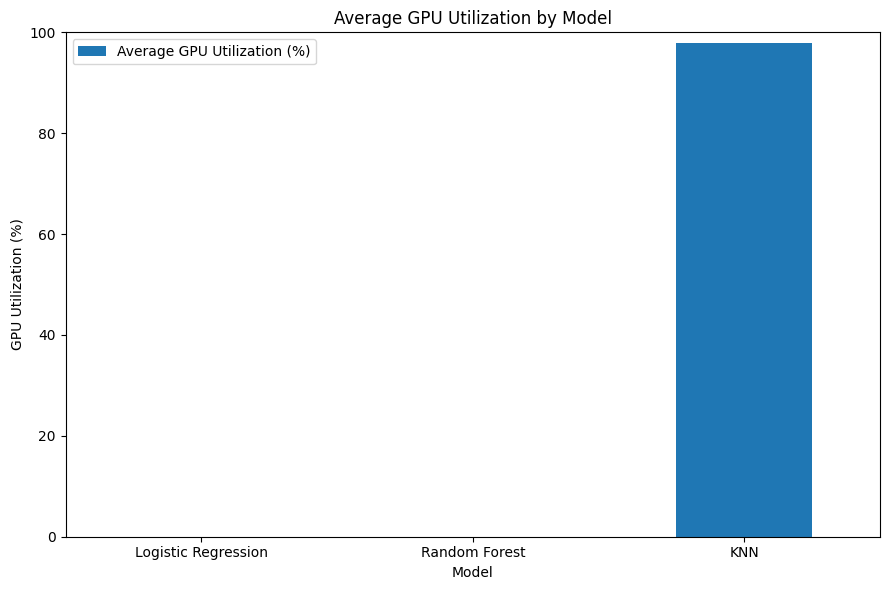

In [ ]:
# GPU Utilization Comparison

import matplotlib.pyplot as plt

gpu_plot = gpu_results.set_index("Model")[
    ["Average GPU Utilization (%)"]
]

gpu_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Average GPU Utilization by Model")
plt.xlabel("Model")
plt.ylabel("GPU Utilization (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Final Model Comparison Table

final_results = results.copy()

final_results["Accuracy (%)"] = final_results["Accuracy"] * 100
final_results["Macro F1 (%)"] = final_results["Macro F1"] * 100
final_results["Weighted F1 (%)"] = final_results["Weighted F1"] * 100

final_results = final_results[
    [
        "Model",
        "Accuracy (%)",
        "Macro F1 (%)",
        "Weighted F1 (%)",
        "Training Time (s)",
        "Inference Time (s)"
    ]
]

print("=== FINAL MODEL COMPARISON ===")
print(final_results.round(2))

=== FINAL MODEL COMPARISON ===
                 Model  Accuracy (%)  Macro F1 (%)  Weighted F1 (%)  \
0  Logistic Regression         63.87         29.74            59.38   
1        Random Forest         72.84         41.11            71.45   
2                  KNN         67.11         46.37            66.58   

   Training Time (s)  Inference Time (s)  
0               5.71                0.77  
1               8.57                2.57  
2               0.07                9.68  


In [ ]:
# Best Model

best_accuracy_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_macro_f1_model = results.loc[
    results["Macro F1"].idxmax(),
    "Model"
]

best_weighted_f1_model = results.loc[
    results["Weighted F1"].idxmax(),
    "Model"
]

print("Best Accuracy Model:", best_accuracy_model)
print("Best Macro F1 Model:", best_macro_f1_model)
print("Best Weighted F1 Model:", best_weighted_f1_model)

Best Accuracy Model: Random Forest
Best Macro F1 Model: KNN
Best Weighted F1 Model: Random Forest


In [ ]:
# Save Baseline Results

baseline_results = results.copy()

print("Baseline results saved successfully.")
print(baseline_results)

Baseline results saved successfully.
                 Model  Accuracy  Macro F1  Weighted F1  Training Time (s)  \
0  Logistic Regression    0.6387    0.2974       0.5938              5.711   
1        Random Forest    0.7284    0.4111       0.7145              8.567   
2                  KNN    0.6711    0.4637       0.6658              0.067   

   Inference Time (s)  
0               0.774  
1               2.566  
2               9.675  
